In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

%matplotlib inline
np.random.seed(0)

class FCNNReg:
    def __init__(self, layer_sizes, hidden_act='tanh', lr=0.01, epochs=1200, tol=1e-5):
        self.layer_sizes = layer_sizes
        self.hidden_act = hidden_act
        self.lr = lr
        self.epochs = epochs
        self.tol = tol
        self.loss_history = []
        
        self.W = [np.random.randn(layer_sizes[i], layer_sizes[i + 1]) * np.sqrt(1.0 / layer_sizes[i])
                  for i in range(len(layer_sizes) - 1)]
        self.b = [np.zeros(layer_sizes[i + 1]) for i in range(len(layer_sizes) - 1)]

    def _act(self, z, kind):
        if kind == 'tanh':
            return np.tanh(z)
        elif kind == 'logistic':
            z_clipped = np.clip(z, -250, 250)
            return 1.0 / (1.0 + np.exp(-z_clipped))
        return z

    def _dact(self, a, kind):
        if kind == 'tanh':
            return 1.0 - a**2
        elif kind == 'logistic':
            return a * (1.0 - a)
        return np.ones_like(a)

    def _forward(self, X):
        As = [X]
        A = X
        for i in range(len(self.W)):
            Z = A @ self.W[i] + self.b[i]
            kind = 'linear' if i == len(self.W) - 1 else self.hidden_act
            A = self._act(Z, kind)
            As.append(A)
        return As

    def compute_loss(self, X, y):
        y = y.reshape(-1, 1) if y.ndim == 1 else y
        As = self._forward(X)
        err = y - As[-1]
        return np.mean(0.5 * err**2)

    def train_sgd(self, X, y):
        y = y.reshape(-1, 1) if y.ndim == 1 else y
        n = len(X)
        self.loss_history = []
        prev_loss = float('inf')
        
        for epoch in range(self.epochs):
            idx = np.random.permutation(n)
            for j in idx:
                x = X[j:j+1]
                t = y[j:j+1]
                As = self._forward(x)
                dA = As[-1] - t
                
                for i in range(len(self.W) - 1, -1, -1):
                    kind = 'linear' if i == len(self.W) - 1 else self.hidden_act
                    dZ = dA * self._dact(As[i + 1], kind)
                    dW = As[i].T @ dZ
                    db = dZ[0]
                    if i > 0:
                        dA = dZ @ self.W[i].T
                    self.W[i] -= self.lr * dW
                    self.b[i] -= self.lr * db
                    
            epoch_loss = self.compute_loss(X, y)
            self.loss_history.append(epoch_loss)
            
            if abs(prev_loss - epoch_loss) < self.tol:
                break
            prev_loss = epoch_loss

    def predict(self, X):
        return self._forward(X)[-1].ravel()

    def count_parameters(self):
        return sum(w.size for w in self.W) + sum(b.size for b in self.b)

In [2]:
def split_60_20_20(X, y, seed=0):
    rng = np.random.default_rng(seed)
    idx = rng.permutation(len(X))
    n = len(X)
    n_tr, n_val = int(n * 0.6), int(n * 0.2)
    return X[idx[:n_tr]], y[idx[:n_tr]], X[idx[n_tr:n_tr+n_val]], y[idx[n_tr:n_tr+n_val]], X[idx[n_tr+n_val:]], y[idx[n_tr+n_val:]]

def standardize_train_val_test(Xtr, Xval, Xte):
    mu = Xtr.mean(axis=0)
    sd = Xtr.std(axis=0) + 1e-8
    return (Xtr - mu) / sd, (Xval - mu) / sd, (Xte - mu) / sd

def rmse_metrics(y_true, y_pred):
    err = y_true - y_pred
    rmse = np.sqrt(np.mean(err**2))
    pct_rmse = (rmse / (np.abs(np.mean(y_true)) + 1e-8)) * 100.0
    return rmse, pct_rmse

def resolve_path(candidates):
    for p in candidates:
        if os.path.exists(p): return p
    raise FileNotFoundError(f"Checked: {candidates}")

p_uni = resolve_path(['Regression/UnivariateData/24.csv', 'data/Regression/UnivariateData/24.csv'])
p_bi = resolve_path(['Regression/BivariateData/24.csv', 'data/Regression/BivariateData/24.csv'])

data_uni = pd.read_csv(p_uni, header=None).values
X_uni, y_uni = data_uni[:, :-1], data_uni[:, -1]

data_bi = pd.read_csv(p_bi, header=None).values
X_bi, y_bi = data_bi[:, :-1], data_bi[:, -1]

Xtr_u, ytr_u, Xval_u, yval_u, Xte_u, yte_u = split_60_20_20(X_uni, y_uni)
Xtr_b, ytr_b, Xval_b, yval_b, Xte_b, yte_b = split_60_20_20(X_bi, y_bi)

Xtr_u_s, Xval_u_s, Xte_u_s = standardize_train_val_test(Xtr_u, Xval_u, Xte_u)
Xtr_b_s, Xval_b_s, Xte_b_s = standardize_train_val_test(Xtr_b, Xval_b, Xte_b)

print(f"Univariate -> Train: {len(Xtr_u)}, Val: {len(Xval_u)}, Test: {len(Xte_u)}")
print(f"Bivariate  -> Train: {len(Xtr_b)}, Val: {len(Xval_b)}, Test: {len(Xte_b)}")

Univariate -> Train: 600, Val: 200, Test: 201
Bivariate  -> Train: 6120, Val: 2040, Test: 2041


In [3]:
uni_configs_1h = [[1, 2, 1], [1, 4, 1], [1, 8, 1], [1, 16, 1]]
uni_results = []

print("==========================================================================")
print("EVALUATING ARCHITECTURES ON VALIDATION SET (DATASET 1: UNIVARIATE)")
print("==========================================================================\n")

for cfg in uni_configs_1h:
    np.random.seed(0)
    m = FCNNReg(cfg, hidden_act='tanh', lr=0.01, epochs=1200, tol=1e-5)
    m.train_sgd(Xtr_u_s, ytr_u)
    r_tr, p_tr = rmse_metrics(ytr_u, m.predict(Xtr_u_s))
    r_val, p_val = rmse_metrics(yval_u, m.predict(Xval_u_s))
    uni_results.append((cfg, m, r_tr, p_tr, r_val, p_val))
    print(f"Architecture {cfg} -> Train RMSE: {r_tr:.4f} ({p_tr:.2f}%) | Val RMSE: {r_val:.4f} ({p_val:.2f}%)")

# Tie-breaker: Lowest Val RMSE -> Fewer Parameters
best_uni_item = min(uni_results, key=lambda x: (x[4], x[1].count_parameters()))
best_uni_cfg, best_uni_model = best_uni_item[0], best_uni_item[1]

print(f"\nSELECTED BEST UNIVARIATE ARCHITECTURE: {best_uni_cfg} (Val RMSE: {best_uni_item[4]:.4f})")

# Summary Table for LaTeX
summary_uni = []
for item in uni_results:
    cfg, m, r_tr, p_tr, r_val, p_val = item
    summary_uni.append({
        "Architecture": str(cfg),
        "Parameters": m.count_parameters(),
        "Train RMSE": f"{r_tr:.4f}",
        "Train %RMSE": f"{p_tr:.2f}%",
        "Val RMSE": f"{r_val:.4f}",
        "Val %RMSE": f"{p_val:.2f}%"
    })
display(pd.DataFrame(summary_uni))

EVALUATING ARCHITECTURES ON VALIDATION SET (DATASET 1: UNIVARIATE)

Architecture [1, 2, 1] -> Train RMSE: 0.1118 (4.07%) | Val RMSE: 0.1099 (4.00%)
Architecture [1, 4, 1] -> Train RMSE: 0.0818 (2.98%) | Val RMSE: 0.0748 (2.72%)
Architecture [1, 8, 1] -> Train RMSE: 0.2374 (8.64%) | Val RMSE: 0.2175 (7.91%)
Architecture [1, 16, 1] -> Train RMSE: 0.0669 (2.43%) | Val RMSE: 0.0637 (2.31%)

SELECTED BEST UNIVARIATE ARCHITECTURE: [1, 16, 1] (Val RMSE: 0.0637)


,Architecture,Parameters,Train RMSE,Train %RMSE,Val RMSE,Val %RMSE
0,"[1, 2, 1]",7,0.1118,4.07%,0.1099,4.00%
1,"[1, 4, 1]",13,0.0818,2.98%,0.0748,2.72%
2,"[1, 8, 1]",25,0.2374,8.64%,0.2175,7.91%
3,"[1, 16, 1]",49,0.0669,2.43%,0.0637,2.31%


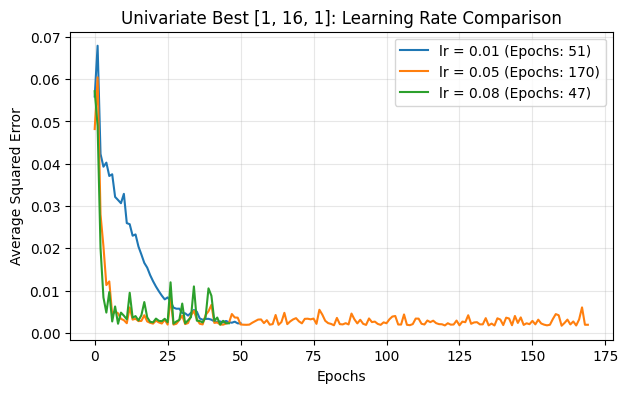

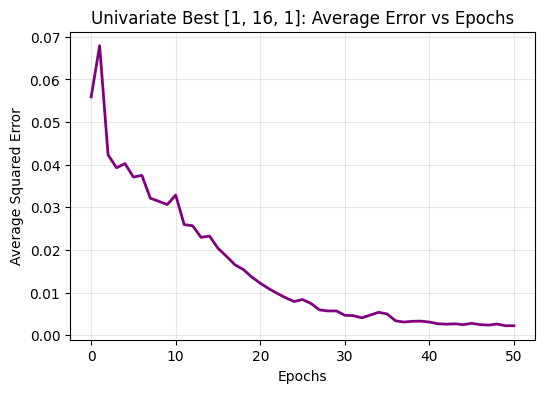

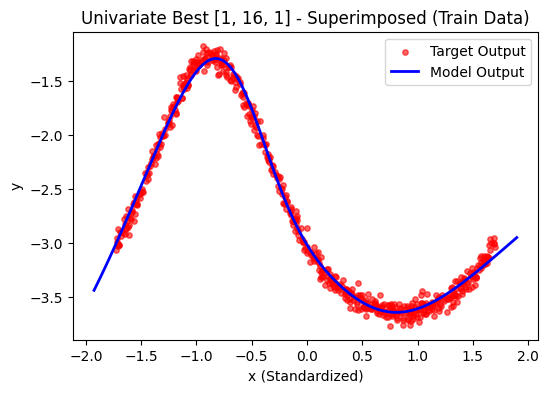

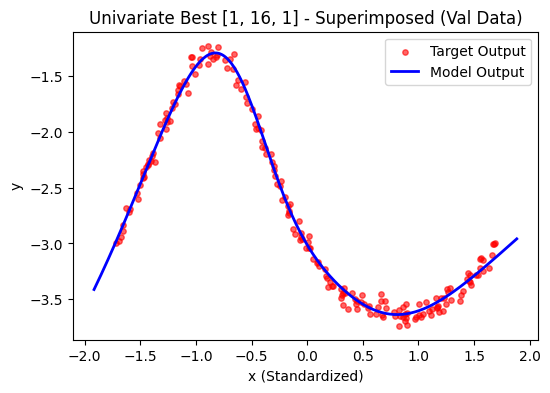

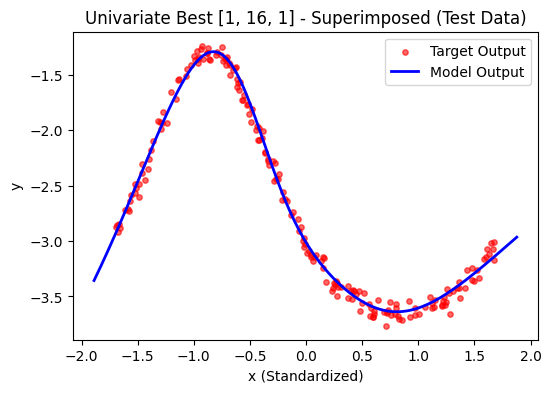

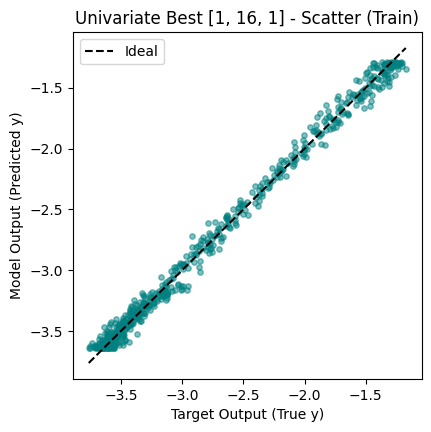

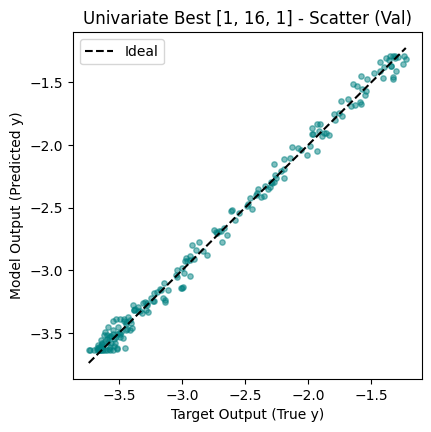

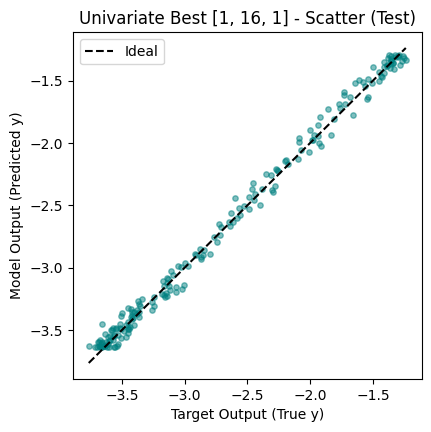

Best Univariate Architecture [1, 16, 1] -> Test RMSE: 0.0665 (2.49%)


In [4]:
# 1. Learning Rate Comparison
plt.figure(figsize=(7, 4))
for lr in [0.01, 0.05, 0.08]:
    np.random.seed(0)
    m = FCNNReg(best_uni_cfg, hidden_act='tanh', lr=lr, epochs=1200, tol=1e-5)
    m.train_sgd(Xtr_u_s, ytr_u)
    plt.plot(m.loss_history, label=f'lr = {lr} (Epochs: {len(m.loss_history)})')
plt.title(f'Univariate Best {best_uni_cfg}: Learning Rate Comparison')
plt.xlabel('Epochs')
plt.ylabel('Average Squared Error')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 2. Average Error vs Epochs for Best Model
plt.figure(figsize=(6, 4))
plt.plot(best_uni_model.loss_history, color='purple', lw=2)
plt.title(f'Univariate Best {best_uni_cfg}: Average Error vs Epochs')
plt.xlabel('Epochs'); plt.ylabel('Average Squared Error')
plt.grid(True, alpha=0.3); plt.show()

# 3. Superimposed Outputs (Train, Val, Test)
for X, y, split in [(Xtr_u_s, ytr_u, 'Train'), (Xval_u_s, yval_u, 'Val'), (Xte_u_s, yte_u, 'Test')]:
    plt.figure(figsize=(6, 4))
    plt.scatter(X[:, 0], y, c='r', s=15, label='Target Output', alpha=0.6)
    xs = np.linspace(X[:, 0].min() - 0.2, X[:, 0].max() + 0.2, 300)[:, None]
    plt.plot(xs[:, 0], best_uni_model.predict(xs), 'b-', lw=2, label='Model Output')
    plt.xlabel('x (Standardized)'); plt.ylabel('y')
    plt.title(f'Univariate Best {best_uni_cfg} - Superimposed ({split} Data)')
    plt.legend(); plt.show()

# 4. Target vs Predicted Scatter Plots
for X, y, split in [(Xtr_u_s, ytr_u, 'Train'), (Xval_u_s, yval_u, 'Val'), (Xte_u_s, yte_u, 'Test')]:
    plt.figure(figsize=(4.5, 4.5))
    preds = best_uni_model.predict(X)
    plt.scatter(y, preds, alpha=0.5, s=15, c='teal')
    lo, hi = min(y.min(), preds.min()), max(y.max(), preds.max())
    plt.plot([lo, hi], [lo, hi], 'k--', lw=1.5, label='Ideal')
    plt.xlabel('Target Output (True y)'); plt.ylabel('Model Output (Predicted y)')
    plt.title(f'Univariate Best {best_uni_cfg} - Scatter ({split})')
    plt.legend(); plt.show()
    
# Test Performance
r_te_u, p_te_u = rmse_metrics(yte_u, best_uni_model.predict(Xte_u_s))
print(f"Best Univariate Architecture {best_uni_cfg} -> Test RMSE: {r_te_u:.4f} ({p_te_u:.2f}%)")

In [5]:
bi_configs = [
    [2, 2, 1], [2, 4, 1], [2, 8, 1], [2, 16, 1],          # 1 hidden layer
    [2, 4, 4, 1], [2, 8, 4, 1], [2, 8, 8, 1], [2, 16, 8, 1] # 2 hidden layers
]
bi_results = []

print("==========================================================================")
print("EVALUATING ARCHITECTURES ON VALIDATION SET (DATASET 2: BIVARIATE)")
print("==========================================================================\n")

for cfg in bi_configs:
    np.random.seed(0)
    m = FCNNReg(cfg, hidden_act='tanh', lr=0.01, epochs=1200, tol=1e-5)
    m.train_sgd(Xtr_b_s, ytr_b)
    r_tr, p_tr = rmse_metrics(ytr_b, m.predict(Xtr_b_s))
    r_val, p_val = rmse_metrics(yval_b, m.predict(Xval_b_s))
    bi_results.append((cfg, m, r_tr, p_tr, r_val, p_val))
    print(f"Architecture {cfg} -> Train RMSE: {r_tr:.4f} ({p_tr:.2f}%) | Val RMSE: {r_val:.4f} ({p_val:.2f}%)")

best_bi_item = min(bi_results, key=lambda x: (x[4], x[1].count_parameters()))
best_bi_cfg, best_bi_model = best_bi_item[0], best_bi_item[1]

print(f"\nSELECTED BEST BIVARIATE ARCHITECTURE: {best_bi_cfg} (Val RMSE: {best_bi_item[4]:.4f})")

# Summary Table for LaTeX
summary_bi = []
for item in bi_results:
    cfg, m, r_tr, p_tr, r_val, p_val = item
    summary_bi.append({
        "Architecture": str(cfg),
        "Hidden Layers": len(cfg) - 2,
        "Parameters": m.count_parameters(),
        "Train RMSE": f"{r_tr:.4f}",
        "Train %RMSE": f"{p_tr:.2f}%",
        "Val RMSE": f"{r_val:.4f}",
        "Val %RMSE": f"{p_val:.2f}%"
    })
display(pd.DataFrame(summary_bi))

EVALUATING ARCHITECTURES ON VALIDATION SET (DATASET 2: BIVARIATE)

Architecture [2, 2, 1] -> Train RMSE: 0.1708 (2.44%) | Val RMSE: 0.1672 (2.40%)
Architecture [2, 4, 1] -> Train RMSE: 0.0667 (0.95%) | Val RMSE: 0.0676 (0.97%)
Architecture [2, 8, 1] -> Train RMSE: 0.0678 (0.97%) | Val RMSE: 0.0696 (1.00%)
Architecture [2, 16, 1] -> Train RMSE: 0.0669 (0.96%) | Val RMSE: 0.0693 (0.99%)
Architecture [2, 4, 4, 1] -> Train RMSE: 0.0829 (1.18%) | Val RMSE: 0.0836 (1.20%)
Architecture [2, 8, 4, 1] -> Train RMSE: 0.0626 (0.89%) | Val RMSE: 0.0639 (0.92%)
Architecture [2, 8, 8, 1] -> Train RMSE: 0.0653 (0.93%) | Val RMSE: 0.0675 (0.97%)
Architecture [2, 16, 8, 1] -> Train RMSE: 0.0685 (0.98%) | Val RMSE: 0.0705 (1.01%)

SELECTED BEST BIVARIATE ARCHITECTURE: [2, 8, 4, 1] (Val RMSE: 0.0639)


,Architecture,Hidden Layers,Parameters,Train RMSE,Train %RMSE,Val RMSE,Val %RMSE
0,"[2, 2, 1]",1,9,0.1708,2.44%,0.1672,2.40%
1,"[2, 4, 1]",1,17,0.0667,0.95%,0.0676,0.97%
2,"[2, 8, 1]",1,33,0.0678,0.97%,0.0696,1.00%
3,"[2, 16, 1]",1,65,0.0669,0.96%,0.0693,0.99%
4,"[2, 4, 4, 1]",2,37,0.0829,1.18%,0.0836,1.20%
5,"[2, 8, 4, 1]",2,65,0.0626,0.89%,0.0639,0.92%
6,"[2, 8, 8, 1]",2,105,0.0653,0.93%,0.0675,0.97%
7,"[2, 16, 8, 1]",2,193,0.0685,0.98%,0.0705,1.01%


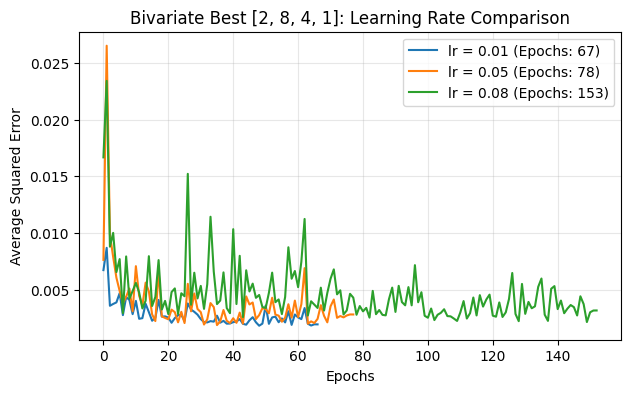

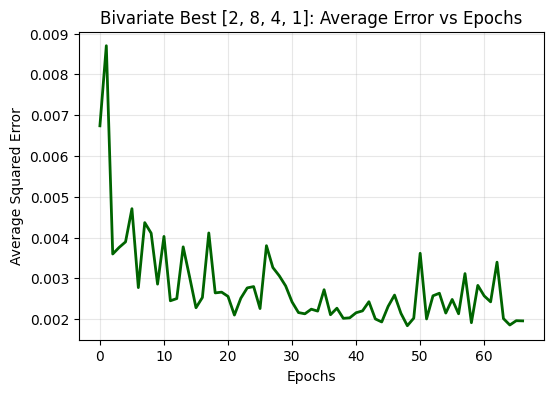

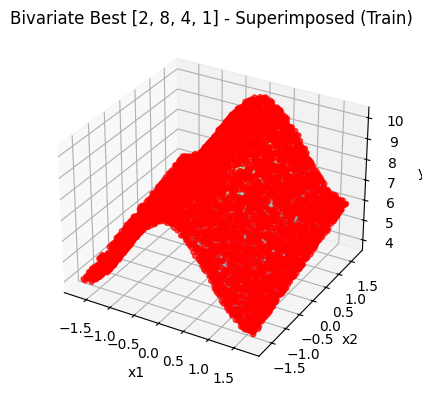

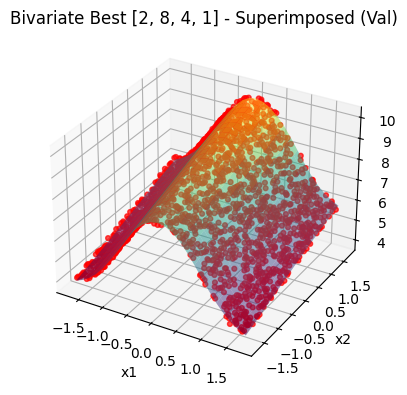

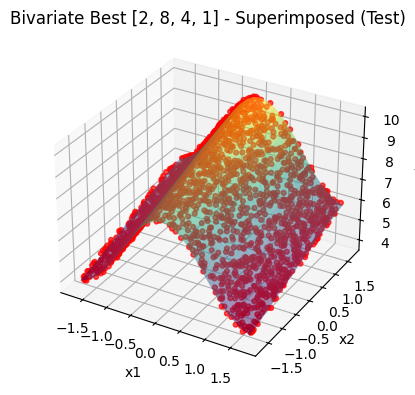

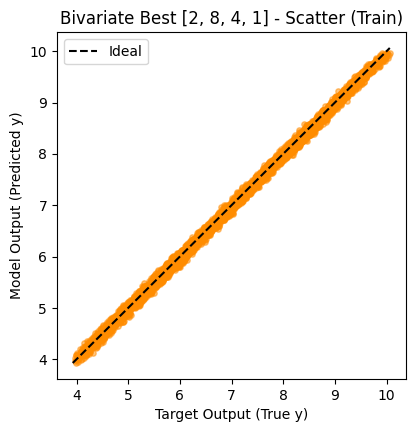

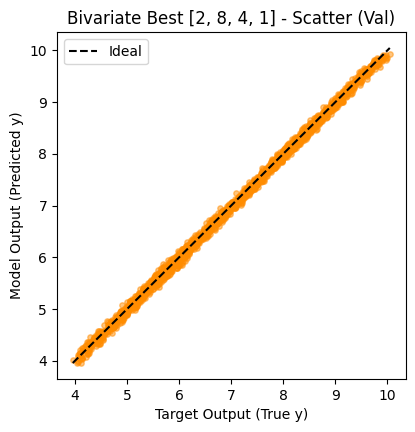

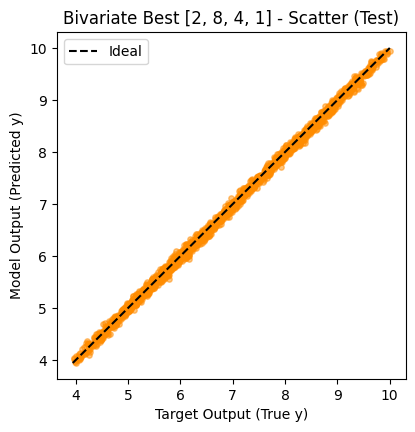

Best Bivariate Architecture [2, 8, 4, 1] -> Test RMSE: 0.0625 (0.90%)


In [6]:
# 1. Learning Rate Comparison
plt.figure(figsize=(7, 4))
for lr in [0.01, 0.05, 0.08]:
    np.random.seed(0)
    m = FCNNReg(best_bi_cfg, hidden_act='tanh', lr=lr, epochs=1200, tol=1e-5)
    m.train_sgd(Xtr_b_s, ytr_b)
    plt.plot(m.loss_history, label=f'lr = {lr} (Epochs: {len(m.loss_history)})')
plt.title(f'Bivariate Best {best_bi_cfg}: Learning Rate Comparison')
plt.xlabel('Epochs'); plt.ylabel('Average Squared Error'); plt.legend(); plt.grid(True, alpha=0.3); plt.show()

# 2. Average Error vs Epochs
plt.figure(figsize=(6, 4))
plt.plot(best_bi_model.loss_history, color='darkgreen', lw=2)
plt.title(f'Bivariate Best {best_bi_cfg}: Average Error vs Epochs')
plt.xlabel('Epochs'); plt.ylabel('Average Squared Error'); plt.grid(True, alpha=0.3); plt.show()

# 3. 3D Superimposed Outputs (Train, Val, Test)
for X, y, split in [(Xtr_b_s, ytr_b, 'Train'), (Xval_b_s, yval_b, 'Val'), (Xte_b_s, yte_b, 'Test')]:
    fig = plt.figure(figsize=(6, 4.5))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(X[:, 0], X[:, 1], y, c='r', s=12, label='Target Output', alpha=0.7)
    gx, gy = np.meshgrid(np.linspace(X[:, 0].min(), X[:, 0].max(), 25), np.linspace(X[:, 1].min(), X[:, 1].max(), 25))
    gz = best_bi_model.predict(np.c_[gx.ravel(), gy.ravel()]).reshape(gx.shape)
    ax.plot_surface(gx, gy, gz, alpha=0.5, cmap='viridis')
    ax.set_xlabel('x1'); ax.set_ylabel('x2'); ax.set_zlabel('y')
    ax.set_title(f'Bivariate Best {best_bi_cfg} - Superimposed ({split})')
    plt.show()

# 4. Target vs Predicted Scatter Plots
for X, y, split in [(Xtr_b_s, ytr_b, 'Train'), (Xval_b_s, yval_b, 'Val'), (Xte_b_s, yte_b, 'Test')]:
    plt.figure(figsize=(4.5, 4.5))
    preds = best_bi_model.predict(X)
    plt.scatter(y, preds, alpha=0.5, s=15, c='darkorange')
    lo, hi = min(y.min(), preds.min()), max(y.max(), preds.max())
    plt.plot([lo, hi], [lo, hi], 'k--', lw=1.5, label='Ideal')
    plt.xlabel('Target Output (True y)'); plt.ylabel('Model Output (Predicted y)')
    plt.title(f'Bivariate Best {best_bi_cfg} - Scatter ({split})')
    plt.legend(); plt.show()

# Test Performance
r_te_b, p_te_b = rmse_metrics(yte_b, best_bi_model.predict(Xte_b_s))
print(f"Best Bivariate Architecture {best_bi_cfg} -> Test RMSE: {r_te_b:.4f} ({p_te_b:.2f}%)")